# Desarrollo de elementos tipo BEAM en diseño de vigas simplemente apoyadas y ejes de transmisión
EL sistema de ecuacuiones que debemos resolver en los casos de elementos tipo BEAM 
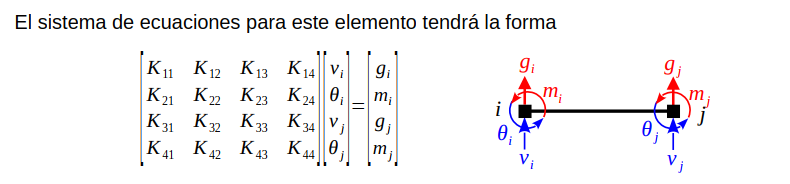
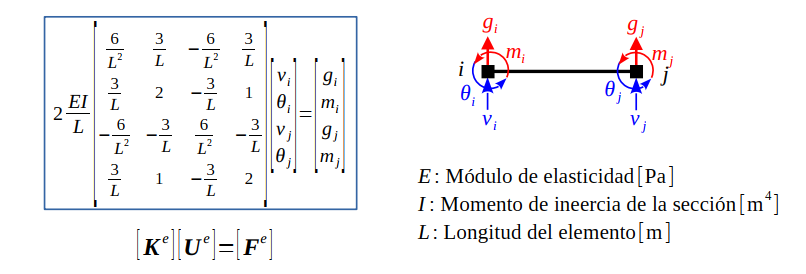
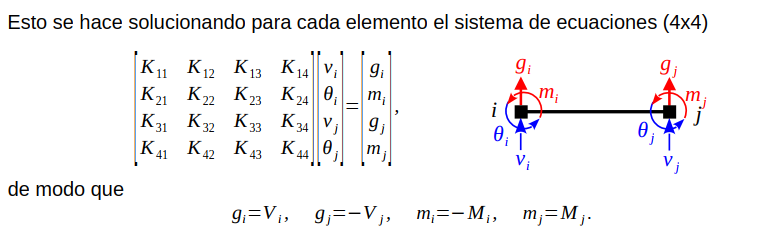
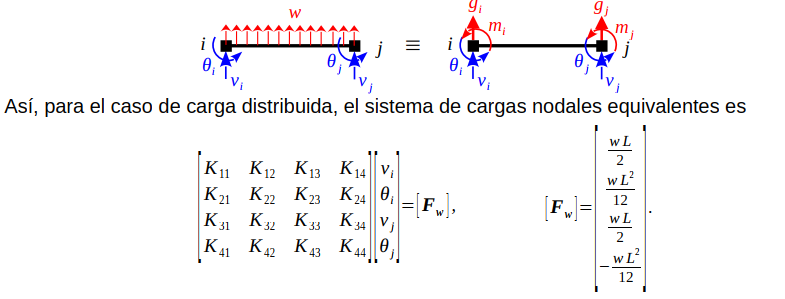


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import CubicHermiteSpline

In [2]:
# =========================================================
# Función: Diagrama de Cortante y Momento Flector
# =========================================================
def plot_BEAM_VM(Mnod, Melem, UG):
    """
    Grafica los diagramas de cortante (V) y momento flector (M)
    para una viga con elementos de Euler-Bernoulli 2D.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.grid(True)
    ax2.grid(True)

    Nelem = Melem.shape[0]

    for i in range(Nelem):
        nod1 = int(Melem[i, 0]) - 1
        nod2 = int(Melem[i, 1]) - 1
        E = Melem[i, 2]
        I = Melem[i, 3]

        x1, x2 = Mnod[nod1, 0], Mnod[nod2, 0]
        l = x2 - x1

        dof1, dof2 = 2 * nod1, 2 * nod1 + 1
        dof3, dof4 = 2 * nod2, 2 * nod2 + 1

        v1, Q1 = UG[dof1, 0], UG[dof2, 0]
        v2, Q2 = UG[dof3, 0], UG[dof4, 0]

        K = 2 * E * I / l
        Ke = K * np.array([
            [6/l**2,  3/l,   -6/l**2,  3/l],
            [3/l,     2,     -3/l,     1],
            [-6/l**2, -3/l,   6/l**2, -3/l],
            [3/l,     1,     -3/l,     2]
        ], dtype=np.float64)

        VM = Ke @ np.array([v1, Q1, v2, Q2])

        # Cortante (V) y momento (M)
        ax1.plot([x1, x2], [VM[0], -VM[2]], '-k', linewidth=2)
        ax2.plot([x1, x2], [-VM[1], VM[3]], '--k', linewidth=2)

    ax1.set_xlabel(r"$x$", fontsize=14)
    ax1.set_ylabel(r"$V$", fontsize=14)
    ax1.set_title("Cortante", fontsize=14)

    ax2.set_xlabel(r"$x$", fontsize=14)
    ax2.set_ylabel(r"$M$", fontsize=14)
    ax2.set_title("Momento flector", fontsize=14)

    plt.tight_layout()
    plt.show()


# =========================================================
# Función: Deformada de la viga
# =========================================================
def plot_BEAM(Mnod, Melem, UG, ax=None):
    """
    Grafica la deformada de la viga usando spline de Hermite.
    Si se pasa 'ax', dibuja sobre ese eje; de lo contrario crea uno nuevo.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))

    ax.grid(True)
    Nelem = Melem.shape[0]

    for i in range(Nelem):
        nod1 = int(Melem[i, 0]) - 1
        nod2 = int(Melem[i, 1]) - 1
        x1, x2 = Mnod[nod1, 0], Mnod[nod2, 0]

        dof1, dof2 = 2 * nod1, 2 * nod1 + 1
        dof3, dof4 = 2 * nod2, 2 * nod2 + 1

        v1, Q1 = UG[dof1, 0], UG[dof2, 0]
        v2, Q2 = UG[dof3, 0], UG[dof4, 0]

        # Hermite spline
        spline = CubicHermiteSpline([x1, x2], [v1, v2], [Q1, Q2])
        x_vals = np.linspace(x1, x2, 100)
        y_vals = spline(x_vals)

        ax.plot(x_vals, y_vals, '-r', linewidth=2)
        ax.plot([x1, x2], [v1, v2], 'or', linewidth=0.75)

    ax.set_xlabel(r"$x$", fontsize=14)
    ax.set_ylabel(r"$v$", fontsize=14)
    ax.set_title("Deformada", fontsize=14)

    return ax
# =========================================================
# Función: Deformada de la viga (comparativa)
# =========================================================
def plot_BEAM_multi(Mnod, Melem, UG, n_sub, ax):
    """
    Dibuja la deformada para el refinamiento n_sub en el mismo gráfico.
    """
    Nelem = Melem.shape[0]
    estilos = ['-', '--', '-.', ':']
    estilo = estilos[(n_sub - 1) % len(estilos)]

    for i in range(Nelem):
        nod1 = int(Melem[i, 0]) - 1
        nod2 = int(Melem[i, 1]) - 1
        x1, x2 = Mnod[nod1, 0], Mnod[nod2, 0]

        dof1, dof2 = 2 * nod1, 2 * nod1 + 1
        dof3, dof4 = 2 * nod2, 2 * nod2 + 1

        v1, Q1 = UG[dof1, 0], UG[dof2, 0]
        v2, Q2 = UG[dof3, 0], UG[dof4, 0]

        spline = CubicHermiteSpline([x1, x2], [v1, v2], [Q1, Q2])
        x_vals = np.linspace(x1, x2, 100)
        y_vals = spline(x_vals)

        ax.plot(x_vals, y_vals, estilo, color='k', linewidth=0.75,
                label=f'{n_sub} subdiv.' if i == 0 else None)

# =========================================================
# Función: Cortante y Momento (comparativa)
# =========================================================
def plot_BEAM_VM_multi(Mnod, Melem, UG, n_sub, axV, axM):
    """
    Dibuja los diagramas de cortante y momento para n_sub en los mismos ejes.
    """
    Nelem = Melem.shape[0]
    estilos = ['-', '--', '-.', ':']
    estilo = estilos[(n_sub - 1) % len(estilos)]

    for i in range(Nelem):
        nod1 = int(Melem[i, 0]) - 1
        nod2 = int(Melem[i, 1]) - 1
        E = Melem[i, 2]
        I = Melem[i, 3]

        x1, x2 = Mnod[nod1, 0], Mnod[nod2, 0]
        l = x2 - x1

        dof1, dof2 = 2 * nod1, 2 * nod1 + 1
        dof3, dof4 = 2 * nod2, 2 * nod2 + 1

        v1, Q1 = UG[dof1, 0], UG[dof2, 0]
        v2, Q2 = UG[dof3, 0], UG[dof4, 0]

        K = 2 * E * I / l
        Ke = K * np.array([
            [6/l**2,  3/l,   -6/l**2,  3/l],
            [3/l,     2,     -3/l,     1],
            [-6/l**2, -3/l,   6/l**2, -3/l],
            [3/l,     1,     -3/l,     2]
        ], dtype=np.float64)

        VM = Ke @ np.array([v1, Q1, v2, Q2])

        # Cortante (V) y momento (M)
        axV.plot([x1, x2], [VM[0], -VM[2]], estilo, color='k', linewidth=0.75,
                 label=f'{n_sub} subdiv.' if i == 0 else None)
        axM.plot([x1, x2], [-VM[1], VM[3]], estilo, color='k', linewidth=0.75,
                 label=f'{n_sub} subdiv.' if i == 0 else None)

In [3]:
# ========================
# Función: matriz de rigidez elemental
# ========================
def mat_Ke(Mnod, Melem, e):
    """
    Calcula la matriz de rigidez elemental Ke para una viga 2D (flexión).
    """
    nod1 = int(Melem[e, 0]) - 1
    nod2 = int(Melem[e, 1]) - 1
    x1 = Mnod[nod1, 0]
    x2 = Mnod[nod2, 0]
    L = x2 - x1
    E = Melem[e, 2]
    I = Melem[e, 3]

    Ke = 2 * (E * I) / L * np.array([
        [6 / L**2,  3 / L,  -6 / L**2,  3 / L],
        [3 / L,     2,      -3 / L,     1],
        [-6 / L**2, -3 / L,  6 / L**2, -3 / L],
        [3 / L,     1,      -3 / L,     2]
    ], dtype=np.float64)
    return Ke


# ========================
# Función: ensamblaje global
# ========================
def mat_KG(Mnod, Melem):
    """
    Ensambla la matriz de rigidez global KG a partir de todos los elementos.
    """
    Nnod = len(Mnod)
    KG = np.zeros((2 * Nnod, 2 * Nnod), dtype=np.float64)

    for e in range(len(Melem)):
        Ke = mat_Ke(Mnod, Melem, e)
        nod1 = int(Melem[e, 0]) - 1
        nod2 = int(Melem[e, 1]) - 1
        dofs = [2 * nod1, 2 * nod1 + 1, 2 * nod2, 2 * nod2 + 1]

        for i in range(4):
            for j in range(4):
                KG[dofs[i], dofs[j]] += Ke[i, j]

    return KG


# ========================
# Función: vector de fuerzas global
# ========================
def vec_FG(Nnod, Load_Moment):
    """
    Crea el vector de fuerzas global FG a partir de la matriz de cargas por nodo y DOF.
    """
    FG = np.zeros((2 * Nnod, 1), dtype=np.float64)
    for i in range(Nnod):
        for j in range(2):
            if not np.isnan(Load_Moment[2 * i + j, 0]):
                FG[2 * i + j, 0] = Load_Moment[2 * i + j, 0]
    return FG


# ========================
# Función: penalización de condiciones de frontera
# ========================
def penalizacion(Nnod, BC_vector, kappa):
    """
    Crea las matrices de penalización para las condiciones de frontera (desplazamientos conocidos).
    """
    Mpenaliz = np.zeros((2 * Nnod, 2 * Nnod), dtype=np.float64)
    Vpenaliz = np.zeros((2 * Nnod, 1), dtype=np.float64)

    for i in range(2 * Nnod):
        if not np.isnan(BC_vector[i, 0]):
            Mpenaliz[i, i] = kappa
            Vpenaliz[i, 0] = kappa * BC_vector[i, 0]

    return Mpenaliz, Vpenaliz
    

# Desarrollo de ejemplo 1
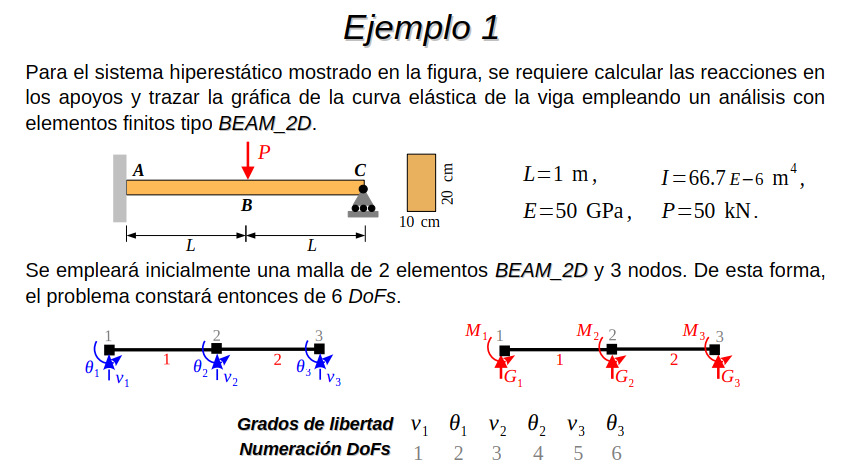

Definimos los grados de libertad (variables) que debemos resolver

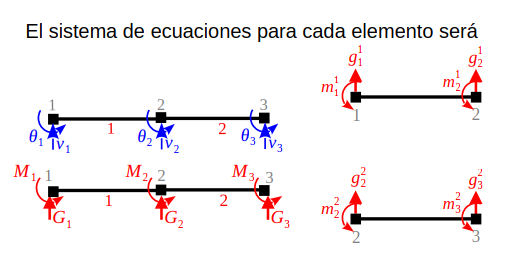

Relacionamos el problema de desplazamientos a las cargas (condiciones de contorno)

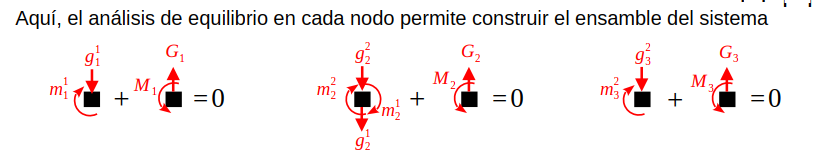
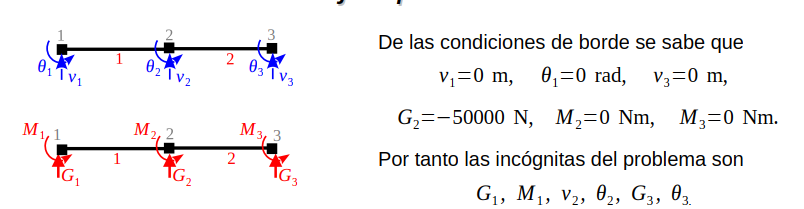

[[ 40019999.99999999  20010000.         -40019999.99999999
   20010000.                 0.                 0.        ]
 [ 20010000.          13340000.         -20010000.
    6670000.                 0.                 0.        ]
 [-40019999.99999999 -20010000.          80039999.99999999
          0.         -40019999.99999999  20010000.        ]
 [ 20010000.           6670000.                 0.
   26680000.         -20010000.           6670000.        ]
 [        0.                 0.         -40019999.99999999
  -20010000.          40019999.99999999 -20010000.        ]
 [        0.                 0.          20010000.
    6670000.         -20010000.          13340000.        ]]
[[     0.]
 [     0.]
 [-50000.]
 [     0.]
 [     0.]
 [     0.]]
[[1.e+20 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+20 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e+20 0.e+00]
 [0.e+00 0.e+00 0

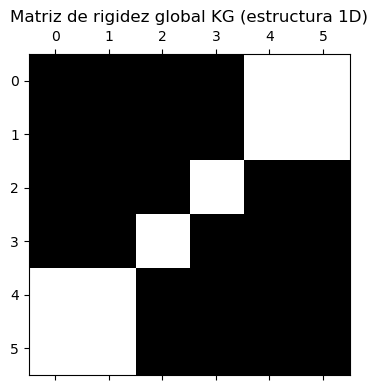

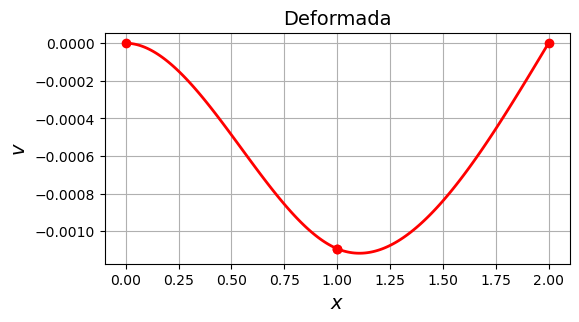

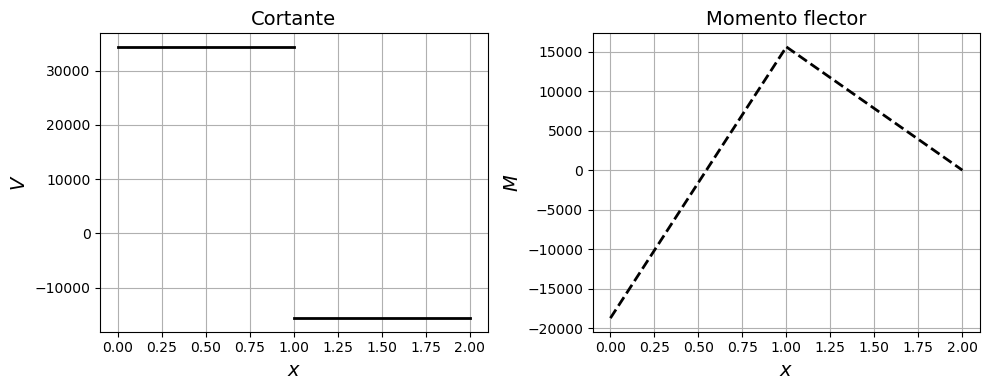

In [4]:
Mnod = np.array([[0], [1], [2]], dtype=np.float64)
Melem = np.array([
    [1, 2, 50e9, 66.7e-6],
    [2, 3, 50e9, 66.7e-6]
], dtype=np.float64)

# Desplazamientos conocidos (NaN = libre)
BC_vector = np.array([
    [0],      # nodo 1, desplazamiento
    [0],      # nodo 1, rotación
    [np.nan], # nodo 2, desplazamiento
    [np.nan], # nodo 2, rotación
    [0],      # nodo 3, desplazamiento
    [np.nan]  # nodo 3, rotación
], dtype=np.float64)

# Cargas y momentos nodales (NaN = sin carga)
Load_Moment = np.array([
    [np.nan], # nodo 1, fuerza
    [np.nan], # nodo 1, momento
    [-5e4],   # nodo 2, fuerza
    [0],      # nodo 2, momento
    [np.nan], # nodo 3, fuerza
    [0]       # nodo 3, momento
], dtype=np.float64)
# Ensamblar el sistema 
KG = mat_KG(Mnod,Melem)
print(KG)
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
FG = vec_FG(len(Mnod), Load_Moment)
print(FG)
Mpenaliz, Vpenaliz = penalizacion(len(Mnod), BC_vector, 1e20)
print(Mpenaliz)
print(Vpenaliz)
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)
# Graficar deformada
plot_BEAM(Mnod, Melem, UG)
# Graficar cortante y momento
plot_BEAM_VM(Mnod, Melem, UG)


# Desarrollo del ejemplo 2
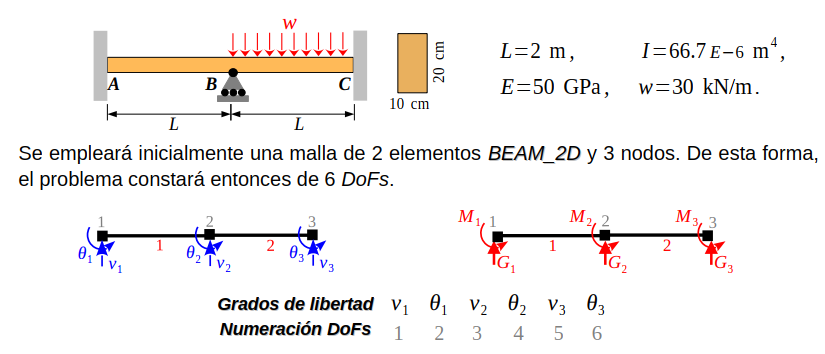
Definimos los grados de libertad que debemos resolver relacionando el problema de desplazamientos con las cargas 
(VARIABLES~CONDICIONES DE CONTORNO)
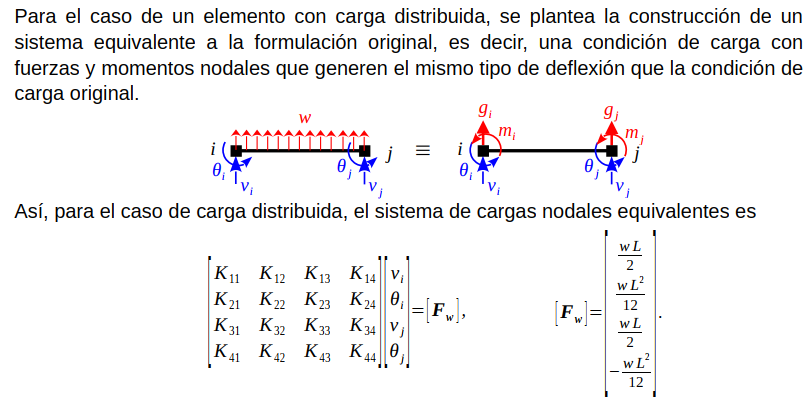
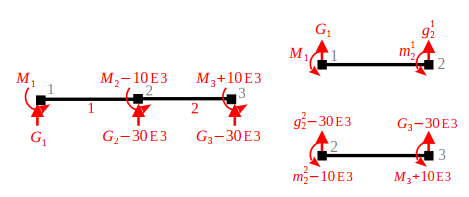
$
[K_e][U_e] = [Fe]+[Fw]
$


[Fw] es el vector que representa la carga distribuida en los nodos del elementos o elementos que tenga esa condición de contorno


[[    nan]
 [    nan]
 [-30000.]
 [-10000.]
 [-30000.]
 [ 10000.]]
[[ 5002500.  5002500. -5002500.  5002500.        0.        0.]
 [ 5002500.  6670000. -5002500.  3335000.        0.        0.]
 [-5002500. -5002500. 10005000.        0. -5002500.  5002500.]
 [ 5002500.  3335000.        0. 13340000. -5002500.  3335000.]
 [       0.        0. -5002500. -5002500.  5002500. -5002500.]
 [       0.        0.  5002500.  3335000. -5002500.  6670000.]]
[[     0.]
 [     0.]
 [-30000.]
 [-10000.]
 [-30000.]
 [ 10000.]]
[[1.e+20 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+20 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+20 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e+20 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e+20]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


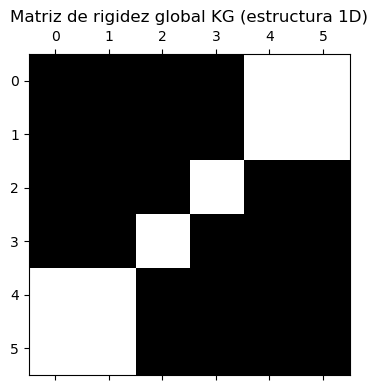

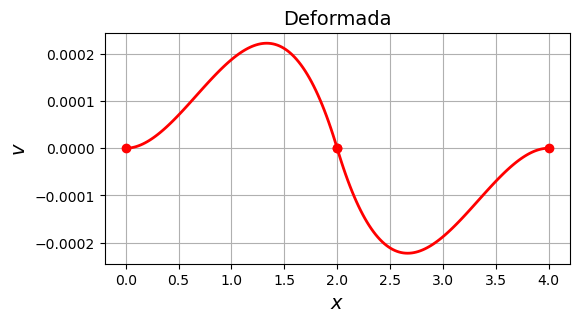

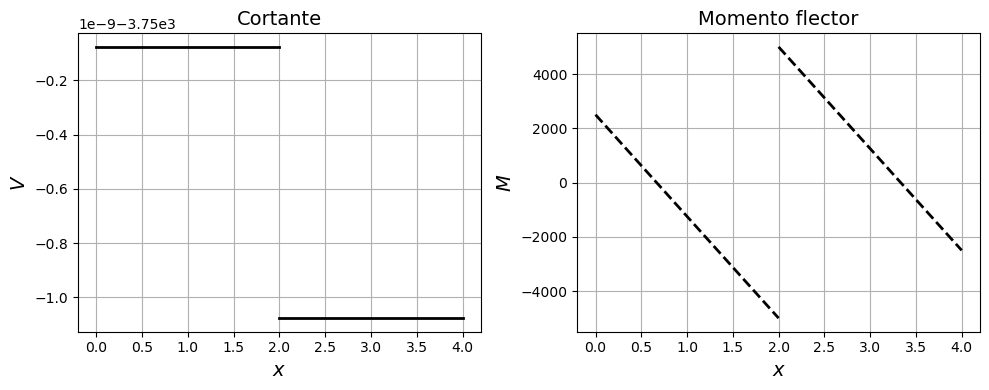

[0. 2. 4.]
[[1]
 [2]]


In [5]:
L = np.float64(2)
w = np.float64(-30e3)
Mnod = np.array([[0*L], [1*L], [2*L]], dtype=np.float64)
Melem = np.array([
    [1, 2, 50e9, 66.7e-6],
    [2, 3, 50e9, 66.7e-6]
], dtype=np.float64)
# Desplazamientos conocidos (NaN = libre)
BC_vector = np.array([
    [0],      # nodo 1, desplazamiento
    [0],      # nodo 1, rotación
    [0],      # nodo 2, desplazamiento
    [np.nan], # nodo 2, rotación
    [0],      # nodo 3, desplazamiento
    [0]  # nodo 3, rotación
], dtype=np.float64)
Load_Moment = np.array([
    [0.0], # nodo 1, fuerza
    [0.0], # nodo 1, momento
    [0.0],   # nodo 2, fuerza
    [0.0],      # nodo 2, momento
    [0.0], # nodo 3, fuerza
    [0.0]       # nodo 3, momento
], dtype=np.float64)
Fw = np.array([
    [np.nan], # nodo 1, fuerza
    [np.nan], # nodo 1, momento
    [(w*L)/2],   # nodo 2, fuerza
    [(w*L**2)/12],      # nodo 2, momento
    [(w*L)/2], # nodo 3, fuerza
    [(-w*L**2)/12]       # nodo 3, momento
], dtype=np.float64)
Load_full = Load_Moment + Fw
print(Load_full)
# Ensamblar el sistema 
KG = mat_KG(Mnod,Melem)
print(KG)
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
FG = vec_FG(len(Mnod), Load_full)
print(FG)
Mpenaliz, Vpenaliz = penalizacion(len(Mnod), BC_vector, 1e20)
print(Mpenaliz)
print(Vpenaliz)
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)
# Graficar deformada
plot_BEAM(Mnod, Melem, UG)
# Graficar cortante y momento
plot_BEAM_VM(Mnod, Melem, UG)

x = Mnod[:,0]
conn = np.int64(Melem[:,0:1])
print(x)
print(conn)

# Englobamiento (Refinamiento de elementos)
El proceso de refinamiento es un proceso por el cual se busca determinar si los resultados obtenidos por medio de una solucion de un dominio discreto son los correctos o el problema es dependiente de la malla.
Este proceso lo veremos mas detallado en casos de simulaciones en 2D y 3D sin embargo la estrategia de solución en este caso es interesante.
Que pasa si mejoramos el numero de elementos por los cuales dividimos cada uno los elementos originales?


In [6]:
def MnodANDMelem_FRAME(Mnod, Melem, E, I, Nelem_seg=1, decimals=12):
    """
    Refina una malla 1D subdividiendo cada elemento en Nelem_seg partes.
    Conserva los nodos originales y agrega los intermedios de forma ordenada.

    Parámetros:
      Mnod : (Nnod,1)  -> coordenadas x
      Melem : (Nelem,2) -> conectividades (1-based)
      E, I : propiedades
      Nelem_seg : subdivisiones por elemento
    """

    Mnod = np.atleast_2d(Mnod)
    Melem = np.atleast_2d(Melem)

    if np.isscalar(Nelem_seg):
        segs = [int(Nelem_seg)] * Melem.shape[0]
    else:
        segs = list(map(int, np.asarray(Nelem_seg)))
        if len(segs) != Melem.shape[0]:
            raise ValueError("Nelem_seg debe tener un valor por elemento.")

    nodes = [float(x) for x in Mnod[:, 0]]
    elementos = []
    next_idx = len(nodes) + 1

    for e, (n1, n2) in enumerate(Melem[:, :2].astype(int)):
        x1 = Mnod[n1 - 1, 0]
        x2 = Mnod[n2 - 1, 0]
        s = segs[e]

        # subdivisión entre x1 y x2
        x_sub = np.linspace(x1, x2, s + 1)

        # asegurar que el nodo inicial y final son los originales
        ids_sub = []
        for xi in x_sub[1:-1]:  # nodos intermedios (no duplicar extremos)
            if not any(np.isclose(xi, np.array(nodes), atol=10**-decimals)):
                nodes.append(round(xi, decimals))
            ids_sub.append(nodes.index(round(xi, decimals)) + 1)

        # nodos del tramo en orden espacial
        nodos_tramo = [n1] + ids_sub + [n2]

        for j in range(len(nodos_tramo) - 1):
            elementos.append([nodos_tramo[j], nodos_tramo[j + 1], E, I])

    # ordenar nodos globalmente por coordenada
    order = np.argsort(nodes)
    Mnod_new = np.array(nodes, dtype=float).reshape(-1, 1)[order]

    # crear mapa antiguo->nuevo índice
    old2new = {i + 1: np.where(order == i)[0][0] + 1 for i in range(len(nodes))}

    # actualizar conectividades
    Melem_new = np.array(
    [[int(old2new[int(i)]), int(old2new[int(j)]), float(E), float(I)] 
     for i, j, _, _ in elementos],
    dtype=object
    )

    return Mnod_new, Melem_new
def vec_Fw(Mnod, Melem, e, w):
    """
    Calcula el vector de cargas nodales equivalentes de un elemento de viga
    sometido a una carga distribuida w[e].
    """
    nod1 = int(Melem[e, 0]) - 1
    nod2 = int(Melem[e, 1]) - 1
    x1 = Mnod[nod1, 0]
    x2 = Mnod[nod2, 0]
    L = x2 - x1

    # Vector de carga equivalente local
    Fw = np.array([
        [ (w[e] * L) / 2 ],
        [ (w[e] * L**2) / 12 ],
        [ (w[e] * L) / 2 ],
        [ (-w[e] * L**2) / 12 ]
    ], dtype=np.float64)

    return Fw


def ensamble_Fw(Mnod, Melem, w):
    """
    Ensambla el vector global de cargas nodales equivalentes
    por carga distribuida w.
    """
    Nnod = len(Mnod)
    Fw_G = np.zeros((2 * Nnod, 1), dtype=np.float64)  # Vector global

    for e in range(len(Melem)):
        Fw = vec_Fw(Mnod, Melem, e, w)
        nod1 = int(Melem[e, 0]) - 1
        nod2 = int(Melem[e, 1]) - 1
        dofs = [2 * nod1, 2 * nod1 + 1, 2 * nod2, 2 * nod2 + 1]
        for i in range(4):
            Fw_G[dofs[i],0] += Fw[i,0]

    return Fw_G
def expand_BC_vector_FRAME(Mnod, Mnod_new, BC_vector):
    """
    Expande el vector de condiciones de frontera (BC_vector) 
    cuando se refina la malla de un marco 1D (BEAM).

    Parámetros
    ----------
    Mnod : ndarray
        Nodos originales (Nx1)
    Mnod_new : ndarray
        Nodos refinados (N'x1)
    BC_vector : ndarray
        Vector de condiciones de frontera original (2N x 1)

    Retorna
    -------
    BC_vector_new : ndarray
        Vector expandido (2N' x 1)
    """
    Nnod_original = Mnod.shape[0]
    Nnod_total = Mnod_new.shape[0]

    # Vector expandido: inicialmente libre (NaN)
    BC_vector_new = np.full((2 * Nnod_total, 1), np.nan)

    # Asociar cada nodo original con su posición en la nueva malla (por coordenadas)
    for i in range(Nnod_original):
        x_old = Mnod[i, 0]
        # Buscar índice del nodo nuevo con la misma coordenada
        idx = np.where(np.isclose(Mnod_new[:, 0], x_old, atol=1e-9))[0]
        if len(idx) > 0:
            idx_new = idx[0]
            # Copiar desplazamiento y rotación (2 dof por nodo)
            BC_vector_new[2 * idx_new:2 * idx_new + 2, 0] = BC_vector[2 * i:2 * i + 2, 0]

    return BC_vector_new

[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-1.00000000e+04]
 [-1.11111111e+03]
 [-2.00000000e+04]
 [ 3.33375283e-09]
 [-2.00000000e+04]
 [-3.33375283e-09]
 [-1.00000000e+04]
 [ 1.11111111e+03]]


C:\Users\david\AppData\Local\Temp\ipykernel_4116\1600164766.py:99: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Fw_G[dofs[i],0] += Fw[i,0]


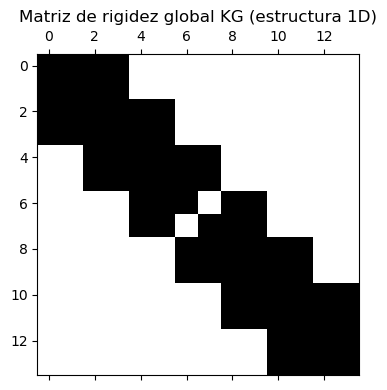

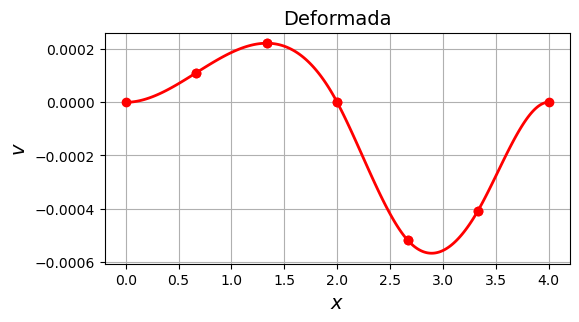

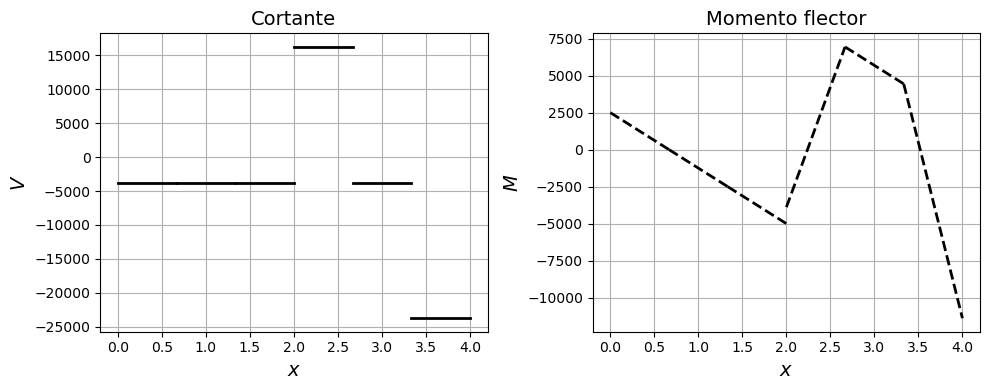

In [7]:
L = np.float64(2)
w = np.float64(-30e3)
Mnod = np.array([[0.],
                 [2.],
                 [4.]])
Melem = np.array([[1, 2],
                  [2, 3]])
E = 5e10
I = 6.67e-5
# Desplazamientos conocidos (NaN = libre)
BC_vector = np.array([
    [0],      # nodo 1, desplazamiento
    [0],      # nodo 1, rotación
    [0],      # nodo 2, desplazamiento
    [np.nan], # nodo 2, rotación
    [0],      # nodo 3, desplazamiento
    [0]  # nodo 3, rotación
], dtype=np.float64)
Load_Moment = np.array([
    [0.0], # nodo 1, fuerza
    [0.0], # nodo 1, momento
    [0.0],   # nodo 2, fuerza
    [0.0],      # nodo 2, momento
    [0.0], # nodo 3, fuerza
    [0.0]       # nodo 3, momento
], dtype=np.float64)
Fw = np.array([
    [np.nan], # nodo 1, fuerza
    [np.nan], # nodo 1, momento
    [(w*L)/2],   # nodo 2, fuerza
    [(w*L**2)/12],      # nodo 2, momento
    [(w*L)/2], # nodo 3, fuerza
    [(-w*L**2)/12]       # nodo 3, momento
], dtype=np.float64)
Load_full = Load_Moment + Fw
# print(Load_full)
# Refinamiento de malla
Mnod_new, Melem_new = MnodANDMelem_FRAME(Mnod, Melem, E, I, 3)
# print(Mnod_new)
# print(Melem_new)
Load_Moment = np.zeros((2*Mnod_new.shape[0],1),dtype=np.float64)
Fw = np.zeros((Melem_new.shape[0],1))
for i in range(Melem_new.shape[0]):
    nod1 = Melem_new[i, 0]
    x1 = Mnod_new[nod1-1, 0]   # acceder con índice 0-based
    if x1 >= L:
        Fw[i] = w
# print(Fw)
Fw_expanded = ensamble_Fw(Mnod_new, Melem_new,Fw)
# print(Fw_expanded)
# Ensamblar el sistema 
KG = mat_KG(Mnod_new,Melem_new)
# print(KG)
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
Load_full = Load_Moment+Fw_expanded
# print(Load_full)
FG = vec_FG(len(Mnod_new), Load_full)
print(FG)
BC_vector_new = expand_BC_vector_FRAME(Mnod, Mnod_new, BC_vector)
# print(BC_vector_new)
Mpenaliz, Vpenaliz = penalizacion(len(Mnod_new), BC_vector_new, 1e20)
# print(Mpenaliz)
# print(Vpenaliz)
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)
# Graficar deformada
plot_BEAM(Mnod_new, Melem_new, UG)
# Graficar cortante y momento
plot_BEAM_VM(Mnod_new, Melem_new, UG)

C:\Users\david\AppData\Local\Temp\ipykernel_4116\1600164766.py:99: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Fw_G[dofs[i],0] += Fw[i,0]


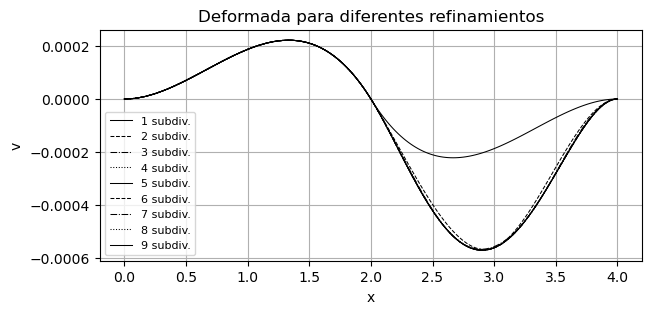

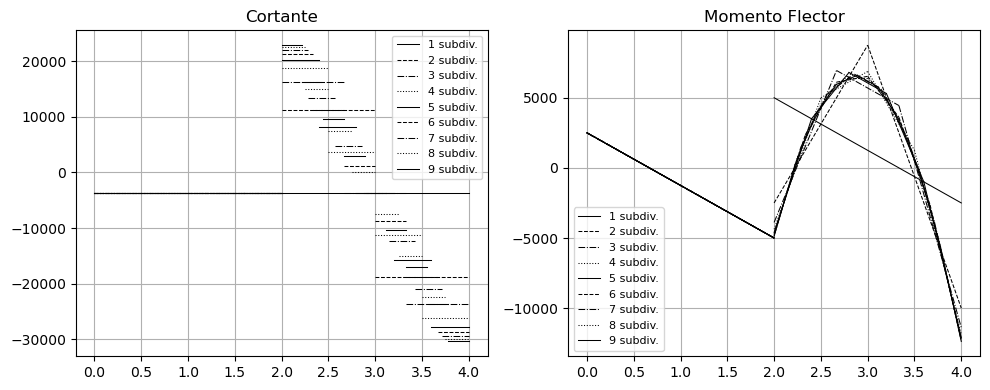

In [8]:
# === Datos del problema ===
L = np.float64(2)
w = np.float64(-30e3)
Mnod = np.array([[0.],
                 [2.],
                 [4.]])
Melem = np.array([[1, 2],
                  [2, 3]])
E = 5e10
I = 6.67e-5

BC_vector = np.array([
    [0], [0],
    [0], [np.nan],
    [0], [0]
], dtype=np.float64)

Load_Moment = np.zeros_like(BC_vector)

# === Crear figuras para todas las deformadas y diagramas ===
fig_def, ax_def = plt.subplots(figsize=(7, 3))
ax_def.grid(True)
ax_def.set_xlabel("x")
ax_def.set_ylabel("v")
ax_def.set_title("Deformada para diferentes refinamientos")

fig_vm, (axV, axM) = plt.subplots(1, 2, figsize=(10, 4))
for ax in (axV, axM):
    ax.grid(True)
axV.set_title("Cortante")
axM.set_title("Momento Flector")

# === Bucle de refinamiento ===
for n_sub in range(1, 10):
    Mnod_new, Melem_new = MnodANDMelem_FRAME(Mnod, Melem, E, I, n_sub)

    Load_Moment = np.zeros((2*Mnod_new.shape[0],1))
    Fw = np.zeros((Melem_new.shape[0],1))
    for i in range(Melem_new.shape[0]):
        nod1 = Melem_new[i, 0]
        x1 = Mnod_new[nod1-1, 0]
        if x1 >= L:
            Fw[i] = w

    Fw_expanded = ensamble_Fw(Mnod_new, Melem_new, Fw)
    KG = mat_KG(Mnod_new, Melem_new)
    Load_full = Load_Moment + Fw_expanded
    FG = vec_FG(len(Mnod_new), Load_full)
    BC_vector_new = expand_BC_vector_FRAME(Mnod, Mnod_new, BC_vector)
    Mpenaliz, Vpenaliz = penalizacion(len(Mnod_new), BC_vector_new, 1e20)
    UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)

    # Graficar sobre las mismas figuras
    plot_BEAM_multi(Mnod_new, Melem_new, UG, n_sub, ax_def)
    plot_BEAM_VM_multi(Mnod_new, Melem_new, UG, n_sub, axV, axM)

# === Leyendas y mostrar ===
ax_def.legend(fontsize=8, loc='best')
axV.legend(fontsize=8, loc='best')
axM.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

16
[[   nan]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [-7000.]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [   nan]
 [-5000.]
 [   nan]]
[[ 0.]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [ 0.]
 [nan]
 [nan]
 [nan]]
[[    0.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [-7000.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [    0.]
 [-5000.]
 [    0.]]
[[1.e+20 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
  0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
  0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
  0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
  0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00
  0.e+00 0.e+00 0.e+00

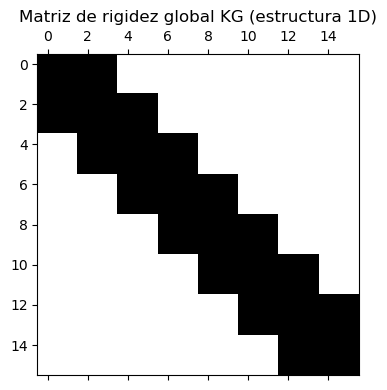

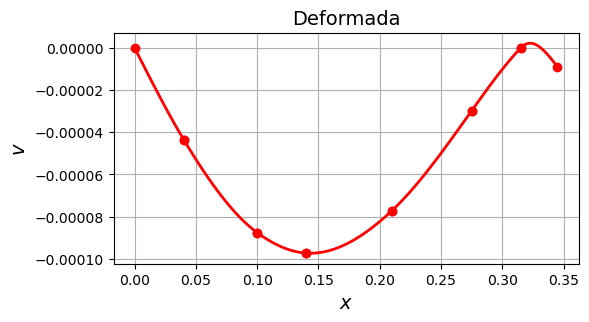

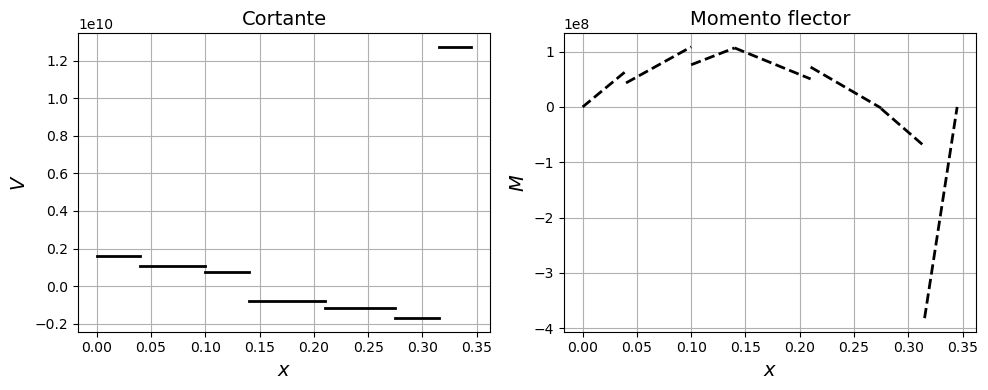

In [9]:
def mat_Ke(Mnod, Melem, e):
    """
    Calcula la matriz de rigidez elemental Ke para una viga 2D (flexión).
    """
    nod1 = int(Melem[e, 0]) - 1
    nod2 = int(Melem[e, 1]) - 1
    x1 = Mnod[nod1, 0]
    x2 = Mnod[nod2, 0]
    L = x2 - x1
    E = Melem[e, 2]
    d = Melem[e, 3]
    I = (np.pi/4 ) * (d/2)**4 
    Ke = 2 * (E * I) / L * np.array([
        [6 / L**2,  3 / L,  -6 / L**2,  3 / L],
        [3 / L,     2,      -3 / L,     1],
        [-6 / L**2, -3 / L,  6 / L**2, -3 / L],
        [3 / L,     1,      -3 / L,     2]
    ], dtype=np.float64)
    return Ke


    
Mnod = (1/1000)* np.array([[0],
                           [40],
                           [100],
                           [140],
                           [210],
                           [275],
                           [315],
                           [345]],dtype=np.float64)
E = np.float64(210e9)
Melem = np.array([[1,2,E,35e-3],
                  [2,3,E,40e-3],
                  [3,4,E,45e-3],
                  [4,5,E,45e-3],
                  [5,6,E,40e-3],
                  [6,7,E,35e-3],
                  [7,8,E,20e-3]],dtype=np.float64)
# Ensamblar el sistema 
KG = mat_KG(Mnod,Melem)
print(KG.shape[0])
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
Load_Moment = np.nan * np.ones((2*len(Mnod),1),dtype=np.float64)
Load_Moment[6,0] = -7e3
Load_Moment[14,0] = -5e3
print(Load_Moment)
BC_vector = np.nan * np.ones((2*len(Mnod),1),dtype=np.float64)
BC_vector[0,0] = 0
BC_vector[12,0] = 0
print(BC_vector)
FG = vec_FG(len(Mnod), Load_Moment)
print(FG)
Mpenaliz, Vpenaliz = penalizacion(len(Mnod), BC_vector, 1e20)
print(Mpenaliz)
print(Vpenaliz)
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)
# Graficar deformada
plot_BEAM(Mnod, Melem, UG)
# Graficar cortante y momento
plot_BEAM_VM(Mnod, Melem, UG)